# 04 Whisper 共享编码器情感分类训练
复用 Whisper Encoder 作为特征提取器，冻结编码器参数，只训练分类头。

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q openai-whisper noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/Emotion-perception-driven-speech-recognition-system


In [2]:
import sys
import time
import copy
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset, random_split
import whisper
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config, LABEL2ID, EMOTION_LABELS
from models.whisper_emotion import WhisperEmotionHead

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

设备: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. 准备数据集

In [3]:
from torch.utils.data import random_split

from preprocessing.whisper_feature_cache import prepare_whisper_feature_dataset

# 提取/缓存 Whisper encoder 池化特征（首次会计算并落盘，后续直接复用）
feature_bs = int(cfg.get("training", {}).get("whisper_feature_batch_size", 8))
feature_workers = int(cfg.get("training", {}).get("whisper_feature_num_workers", 0))
feature_prefetch = int(cfg.get("training", {}).get("whisper_feature_prefetch_factor", 2))

dataset, meta = prepare_whisper_feature_dataset(
    cfg=cfg,
    device=device,
    subsets=("ravdess", "casia", "tess", "esd"),
    batch_size=feature_bs,
    feature_dtype="float16",
    overwrite=False,
    num_workers=feature_workers,
    prefetch_factor=feature_prefetch,
)
print(f"特征缓存元信息: {meta}")

# 划分 train/val/test
total = len(dataset)
train_n = int(total * cfg["training"]["train_ratio"])
val_n = int(total * cfg["training"]["val_ratio"])
test_n = total - train_n - val_n

gen = torch.Generator().manual_seed(cfg["training"]["seed"])
train_set, val_set, test_set = random_split(dataset, [train_n, val_n, test_n], generator=gen)

bs = int(cfg["training"]["batch_size"])
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False, pin_memory=True)

print(
    f"训练: {train_n}, 验证: {val_n}, 测试: {test_n}, "
    f"batch_size: {bs}, feature_batch_size: {feature_bs}, "
    f"feature_num_workers: {feature_workers}, feature_prefetch_factor: {feature_prefetch}"
)

共 40237 个样本
特征缓存元信息: {'whisper_size': 'small', 'num_samples': 40237, 'enc_dim': 768, 'feature_dtype': 'float16'}
训练: 32189, 验证: 4023, 测试: 4025, batch_size: 256, feature_batch_size: 64, feature_num_workers: 8, feature_prefetch_factor: 2


## 2. 构建模型

In [4]:
from models.whisper_emotion import WHISPER_DIMS

# 兼容：无论是否复用缓存/是否重启 kernel，都从配置中读取 whisper_size
whisper_size = cfg["model"]["whisper_size"]

enc_dim = WHISPER_DIMS[whisper_size]
num_classes = cfg["emotion"]["num_classes"]

classifier = nn.Sequential(
    nn.Linear(enc_dim, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, 64),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(64, num_classes),
).to(device)

trainable = sum(p.numel() for p in classifier.parameters())
print(f"分类器可训练参数: {trainable:,}")

分类器可训练参数: 213,702


## 3. 训练

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    classifier.parameters(),
    lr=cfg['training']['learning_rate'],
    weight_decay=cfg['training']['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5,
)

epochs = cfg['training']['epochs']
patience = cfg['training']['patience']
best_val_loss = float('inf')
best_cls_state = None
wait = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    t0 = time.time()

    classifier.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = classifier(feats)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * feats.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total += feats.size(0)

    classifier.eval()
    vl_loss, vl_correct, vl_total = 0, 0, 0
    with torch.no_grad():
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            logits = classifier(feats)
            loss = criterion(logits, labels)
            vl_loss += loss.item() * feats.size(0)
            vl_correct += (logits.argmax(1) == labels).sum().item()
            vl_total += feats.size(0)

    tr_loss /= tr_total; tr_acc = tr_correct / tr_total
    vl_loss /= vl_total; vl_acc = vl_correct / vl_total
    scheduler.step(vl_loss)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:3d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | {elapsed:.1f}s')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_cls_state = copy.deepcopy(classifier.state_dict())
        wait = 0
        print(f'  -> 最佳模型已保存')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 连续 {patience} 轮无改善')
            break

os.makedirs(cfg['paths']['checkpoints'], exist_ok=True)
torch.save({
    'classifier_state': best_cls_state,
    'whisper_size': whisper_size,
    'num_classes': cfg['emotion']['num_classes'],
}, cfg['paths']['best_shared_model'])
np.savez(os.path.join(cfg['paths']['checkpoints'], 'shared_history.npz'), **history)
print(f'模型已保存至: {cfg["paths"]["best_shared_model"]}')

Epoch   1/100 | Train Loss: 1.4604 Acc: 0.3874 | Val Loss: 1.0826 Acc: 0.5946 | 1.1s
  -> 最佳模型已保存
Epoch   2/100 | Train Loss: 1.0078 Acc: 0.6132 | Val Loss: 0.8042 Acc: 0.7114 | 0.7s
  -> 最佳模型已保存
Epoch   3/100 | Train Loss: 0.8194 Acc: 0.6929 | Val Loss: 0.6698 Acc: 0.7562 | 0.8s
  -> 最佳模型已保存
Epoch   4/100 | Train Loss: 0.7075 Acc: 0.7336 | Val Loss: 0.5991 Acc: 0.7805 | 0.8s
  -> 最佳模型已保存
Epoch   5/100 | Train Loss: 0.6442 Acc: 0.7556 | Val Loss: 0.5488 Acc: 0.7994 | 0.7s
  -> 最佳模型已保存
Epoch   6/100 | Train Loss: 0.5975 Acc: 0.7734 | Val Loss: 0.5173 Acc: 0.8086 | 1.0s
  -> 最佳模型已保存
Epoch   7/100 | Train Loss: 0.5552 Acc: 0.7900 | Val Loss: 0.5026 Acc: 0.8071 | 0.7s
  -> 最佳模型已保存
Epoch   8/100 | Train Loss: 0.5328 Acc: 0.8026 | Val Loss: 0.4615 Acc: 0.8277 | 0.7s
  -> 最佳模型已保存
Epoch   9/100 | Train Loss: 0.5014 Acc: 0.8128 | Val Loss: 0.4371 Acc: 0.8347 | 0.7s
  -> 最佳模型已保存
Epoch  10/100 | Train Loss: 0.4859 Acc: 0.8184 | Val Loss: 0.4300 Acc: 0.8446 | 0.8s
  -> 最佳模型已保存
Epoch  11/100 | Trai

## 4. 训练曲线

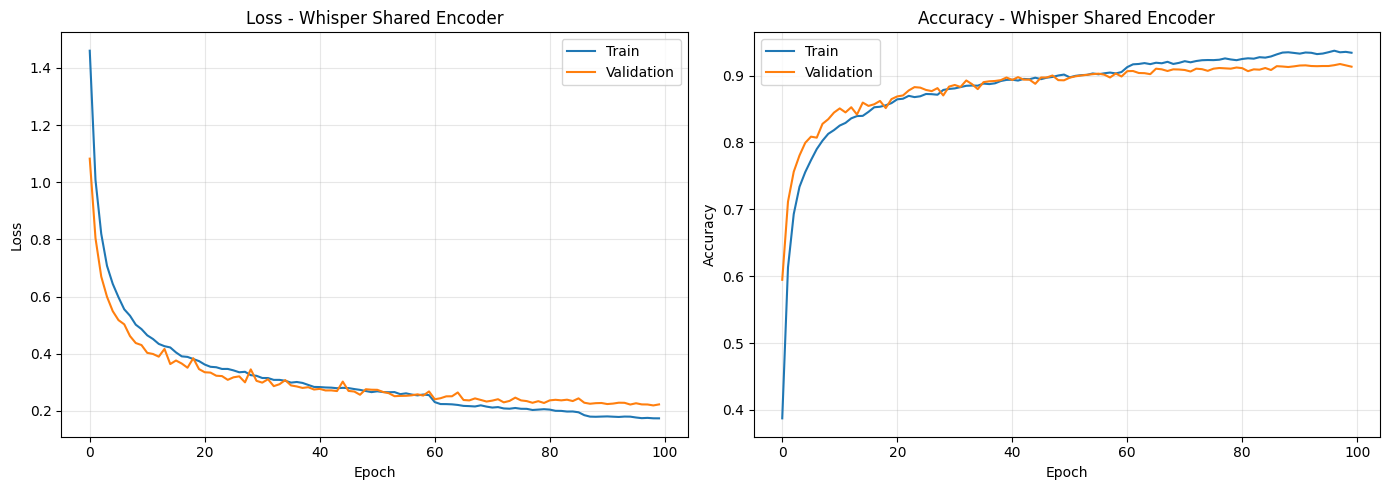

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss - Whisper Shared Encoder')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy - Whisper Shared Encoder')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'shared_training_curves.png'), dpi=150)
plt.show()

## 5. 测试集评估

              precision    recall  f1-score   support

       happy       0.87      0.89      0.88       742
       angry       0.95      0.95      0.95       817
         sad       0.95      0.94      0.95       761
     neutral       0.94      0.97      0.96       809
        fear       0.84      0.76      0.80        96
    surprise       0.91      0.88      0.90       800

    accuracy                           0.92      4025
   macro avg       0.91      0.90      0.90      4025
weighted avg       0.92      0.92      0.92      4025



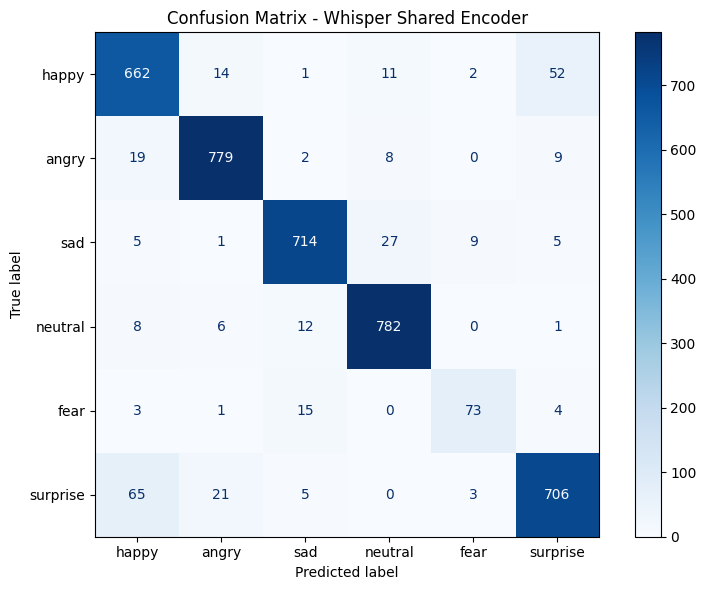

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

classifier.load_state_dict(best_cls_state)
classifier.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for feats, labels in test_loader:
        feats = feats.to(device)
        preds = classifier(feats).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

print(classification_report(all_labels_list, all_preds, target_names=EMOTION_LABELS, zero_division=0))

cm = confusion_matrix(all_labels_list, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Whisper Shared Encoder')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'shared_confusion_matrix.png'), dpi=150)
plt.show()

## 6. 对比两个模型
如果之前已经训练过 CNN+BiLSTM+Attention 模型，可以加载对比。

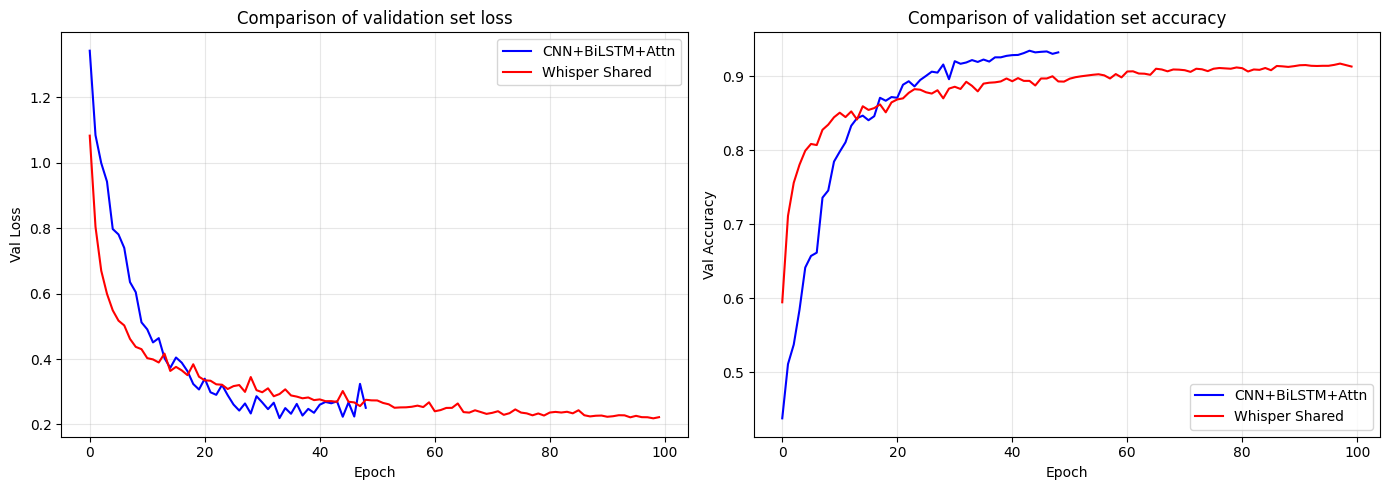

In [8]:
emotion_hist_path = os.path.join(cfg['paths']['checkpoints'], 'emotion_history.npz')
shared_hist_path = os.path.join(cfg['paths']['checkpoints'], 'shared_history.npz')

if os.path.isfile(emotion_hist_path) and os.path.isfile(shared_hist_path):
    eh = np.load(emotion_hist_path)
    sh = np.load(shared_hist_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(eh['val_loss'], label='CNN+BiLSTM+Attn', color='blue')
    ax1.plot(sh['val_loss'], label='Whisper Shared', color='red')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
    ax1.set_title('Comparison of validation set loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    ax2.plot(eh['val_acc'], label='CNN+BiLSTM+Attn', color='blue')
    ax2.plot(sh['val_acc'], label='Whisper Shared', color='red')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy')
    ax2.set_title('Comparison of validation set accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'model_comparison.png'), dpi=150)
    plt.show()
else:
    print('缺少其中一个模型的训练历史，跳过对比。')